# Sherrington-Kirkpatrick model

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$This notebook shows how to generate instances of the Sherrington-Kirkpatrick model and how to estimate some of its properties.

**Table of contents**
1. Import
2. Generation of the instances
3. Average-case upper bound on the 1-norm and operator-norm
4. Best hyperparameters for the quantum-enhanced Monte Carlo trial move
5. Spectral gap calculation
6. Spectral gap plots
7. Classical queries calculation
8. Classical queries plots

## Import

These are the modules used within the notebook. If _monaqa2_ has not been installed, we need to include its path among those reachable from Python. From this `/notebooks` folder, that is just one folder up.

In [15]:
import sys;
if ".." not in sys.path: sys.path.append("..") # allows us to have visibility on our package without installing it in editing mode
import matplotlib.pyplot as plt
from monaqa2.data.hyperparams import load_best_qemc_gamma_t, export_best_gamma_t_h5
from monaqa2.data.instances import load_instances
from monaqa2.data.plot_main import plot_spectral_gap_vs_beta, plot_spectral_gap_vs_n,\
plot_last_step_classical_queries_and_spectral_gap_vs_n
from monaqa2.data.spectral_gap import run_experiment_to_generate_spectral_gaps, load_spectral_gap
from monaqa2.data.classical_query import run_experiment_to_generate_classical_queries
from monaqa2.mcmc.model import IsingModel, RandomIsingModel
import numpy as np

## Generation of the instances

The instances of an $n$-spin SK model are generated by:

1. sampling $n$ field terms from a Gaussian distribution with mean zero and variance one, $h_i \sim \mathcal{N}(0, 1)$;
2. sampling $\binom{n}{2}$ coupling terms from a Gaussian distribution with mean zero and variance one, $J_{ij} \sim \mathcal{N}(0, 1)$ for $i < j$;
3. determining the normalization factor
   $$\alpha=\sqrt{\frac{n}{\sum_i h_i^2+\sum_{i<j}J_{ij}^2}};$$
4. normalizing the coefficients, $\tilde{h}_i = \alpha h_i$ and $\tilde{J}_{ij} = \alpha J_{ij}$.

(CHECK GM) The normalization is useful because... Alternatively, one could sample directly $\tilde h_i,\tilde J_{ij}\sim \mathcal{N}(0,\frac{2}{n+1})$, at the cost of having $\mathbb{E}[|(h,J)|_2^2] = n$ instead of $|(h,J)|_2^2=n$.

Instances can be generated randomly using the `RandomIsingModel` class:

In [ ]:
n = 3
random_model = RandomIsingModel(n=n, seed=1234)
print(f"Random model h=\n{random_model.h_rescaled}")
print(f"Random model J=\n{random_model.J_rescaled}")

or created manually using `IsingModel` class:

In [ ]:
fixed_model = IsingModel.from_coefficients(
    n=n, 
    coefficients=np.hstack([random_model.h_rescaled, random_model.J_rescaled[np.triu_indices(n=n,k=1)]])
)
print(f"Fixed model h=\n{fixed_model.h_rescaled}")
print(f"Fixed model J=\n{fixed_model.J_rescaled}")

The instances used in this work are the same as those used in [From quantum-enhanced to quantum-inspired Monte Carlo, Phys. Rev. A 111, 042615](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.111.042615), whose code is available here: [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc). These can be loaded using the following utilities.

In [ ]:
n = 3 # between 3 and 10 included
idx = 0 # between 0 and 99 included
loaded_ising_model = load_instances(n, idx)
print(f"Loaded model h=\n{loaded_ising_model.h_rescaled}")
print(f"Loaded model J=\n{loaded_ising_model.J_rescaled}")

The source of these instances is the `instances.json` file from [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc), which we processed into HDF5 format in our repository at `data/ising_instances.hdf5`.

## Average-case upper bounds on the 1-norm and operator norm

Let $c=(h_1,\ldots,h_n,J_{12},\ldots,J_{n-1,n})\in\mathbb R^m$, with $m=n+\binom n2$, denote the unnormalized Gaussian coefficients, with $c_i \sim \mathcal{N}(0,1)$, and let $\tilde c$ denote the normalized coefficients, i.e. $\tilde c=\sqrt n\,c/\|c\|_2$.

Since $c$ is a high-dimensional Gaussian vector, we have $\|c\|_1\simeq m\sqrt{2/\pi}$ and $\|c\|_2\simeq \sqrt m$. Therefore, the **typical 1-norm** of the normalized coefficients $\tilde c$ scales as

$$
\|\tilde c\|_1
=
\sqrt n\,\frac{\|c\|_1}{\|c\|_2}
\simeq
\sqrt n\,\frac{m\sqrt{2/\pi}}{\sqrt m}
=
\sqrt n\sqrt{\frac{2m}{\pi}}
=
n\sqrt{\frac{n+1}{\pi}}
\sim
\frac{1}{\sqrt\pi}n^{3/2}.
$$

We also find numerically that a reasonable upper bound for the **operator norm** of a typical instance grows as $n$.

The upper bounds can be validated against the following snippet:

In [19]:
def one_norm_ub(m):
    return np.abs(m.h_rescaled).sum() + np.abs(np.triu(m.J_rescaled, 1)).sum()

def op_norm_ub(m):
    return np.abs(m.energies_rescaled).max()

N_MODELS = 30
ns = np.array(range(5, 24+1))
models = [[RandomIsingModel(n, seed=N_MODELS * n + i) for i in range(N_MODELS)] for n in ns]
U1 = np.load("../data/sk_upper_bound_one_norm.npy") # np.array([[one_norm_ub(m) for m in row] for row in models])
U2 = np.load("../data/sk_upper_bound_op_norm.npy")  # np.array([[op_norm_ub(m) for m in row] for row in models])

This results in the plot:

In [24]:
plt.figure(figsize=(8, 4))
plt.errorbar(ns, U1.mean(1), yerr=U1.std(1), fmt="o", capsize=3, label="Empirical 1-norm UB")
plt.errorbar(ns, U2.mean(1), yerr=U2.std(1), fmt="o", capsize=3, label="Empirical operator-norm UB")
plt.plot(ns, ns**1.5 / np.sqrt(np.pi), "--", label=r"Expected 1-norm UB: $n^{3/2}/\sqrt{\pi}$")
plt.plot(ns, ns, "--", label=r"Expected operator-norm UB: $2n$")
plt.title("Empirical vs expected upper bounds on 1-norm and operator norm")
plt.xlabel(r"$n$")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("plots/1_sk_upper_bounds.png", dpi=300, bbox_inches="tight")
plt.close()

![plots/1_sk_upper_bounds.png](plots/1_sk_upper_bounds.png)

## Best hyperparameters for the quantum-enhanced Monte Carlo trial move

The repository [https://github.com/petr-ivashkov/quantum-mcmc](https://github.com/petr-ivashkov/quantum-mcmc) has already analyzed the instances in the `instances.json` file and determined the best hyperparameters $(\gamma, t)$ for the quantum-enhanced Monte Carlo trial move. These results are available in that repository in the folder `data/grid_search_n<n>[_fine].json` for $n$ up to 10.

The method `monaqa2.data.hyperparams.export_best_gamma_t_h5` processes these JSON files and generates the file `data/best_hyperparams_qemc.hdf5`, which is available in our repository. Therefore, for the set of pre-generated instances we have imported, we do not need to run any hyperparameter optimization routine ourselves.

The hyperparameters for the pre-generated set of instances can be loaded with the following method:

In [13]:
n = 3 # between 3 and 10 included
idx = 0 # between 0 and 99 included
load_best_qemc_gamma_t(n, idx)

(0.4631578947368421, 17.23404255319149)

## Spectral gap calculation

For each pre-generated instance, proposal rule, and inverse temperature $\beta$, we compute the spectral gap of the corresponding transition matrix $P$.

Determining the spectral gap
$
\delta = 1 -
\max\left\{
|\lambda|:\lambda\in\operatorname{spec}(X),\ \lambda\neq 1
\right\}
$
requires an eigendecomposition. Note that the discriminant matrix $X$, which for reversible chains can be easily calculated as $X_{yx}=\sqrt{P_{yx}P_{xy}}$, is similar to $P$ and therefore shares the same spectrum, while also being symmetric, which allows us to use the method `numpy.linalg.eigvalsh`. 

The code below finds the spectral gaps for transition matrices:

* for all system sizes $n=3,\ldots,10$ and all instance indices $\mathrm{idx}=0,\ldots,99$;
* for all inverse temperatures
  $$
  \beta\in\{0.01,0.02,\ldots,0.10,0.20,0.30,\ldots,1.00,2,3,\ldots,10,20,30,\ldots,100\};
  $$
* for all proposal rules `uniform`, `local1`, `local2`, `local3`, `qemc`, and `layden`;
* for the Metropolis-Hastings acceptance rule, corresponding to the parameter $a=\infty$. Only a subset of the results is currently computed for the Glauber rule ($a=1$), and for the generalized Glauber rule with exponent $10$ ($a=10$).

To reproduce the spectral gap calculations, you can run the following (**warning, takes a lot of time**):

In [9]:
# run_experiment_to_generate_spectral_gaps()

The results are saved in pandas pickle format at `data/spectral_gaps_merged.pkl`. The module `monaqa2.data.spectral_gap` provides a convenient way to retrieve the precomputed results through the method `load_spectral_gap(proposal, a)`, which returns a pandas table containing the results for all system sizes $n$, instance indices, and inverse temperatures $\beta$ for a fixed proposal rule and acceptance rule. 

The proposal rule can be one of `uniform`, `local1`, `local2`, `local3`, `qemc`, or `layden`, while the acceptance parameter can be one of $a=\infty$, $a=1$, or $a=10$. At the moment, only the results for $a=\infty$, corresponding to the Metropolis-Hastings acceptance rule, are fully completed.

In [11]:
load_spectral_gap("uniform", a=1).head()

,n,idx,beta,delta
0,3,0,0.01,0.492367
1,3,0,0.02,0.484742
2,3,0,0.03,0.477132
3,3,0,0.04,0.469544
4,3,0,0.05,0.461987


## Spectral-gap plots

We can plot the spectral gap of the trial moves as a function of the inverse temperature $\beta$, for fixed $n \in \{3, ..., 10\}$.

Note that the best classical move is the uniform move in both the high- and low-temperature regimes, with the local move showing comparable performance only around $\beta=1$. The quantum-enhanced move shows an improvement over the best classical move at low temperatures.

These plots are comparable to the evidence presented in [*Quantum-enhanced Markov chain Monte Carlo*](https://www.nature.com/articles/s41586-023-06095-4) for dense Ising models; see [Supplementary Material Fig. S2, S3, and Table S1](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-023-06095-4/MediaObjects/41586_2023_6095_MOESM1_ESM.pdf).


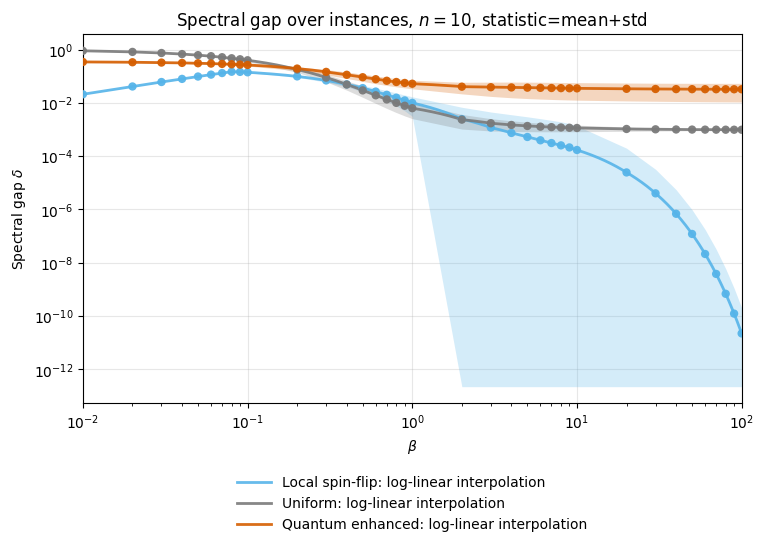

In [4]:
fix, ax = plot_spectral_gap_vs_beta(fixed_n=10)

The scaling of the spectral gap with the system size, at fixed inverse temperature, is shown below.

The low-temperature regime, which is the most promising regime for a quantum speedup, is characterized by a local spin-flip move that is hard to fit reliably. We expect it to perform worse than the uniform move, both in terms of the actual spectral gap on the tested samples and in terms of scaling. While the former is clear, the latter is not. In fact, for $n=10$ and sometimes also for $n=9$, the spectral gap of the local move falls below machine precision for the hardest instances. In our statistics, this causes these values to be removed, thereby biasing the estimate: for the uniform and quantum-enhanced moves, the average is taken over all 100 instances for each $n$, whereas for the local move it is taken only over the subset of instances whose spectral gaps remain numerically resolvable. This introduces the artifact that, below a certain threshold, the spectral gap appears to flatten, which distorts the expected scaling, although the expected scaling remains clearly within the large standard-deviation bands.

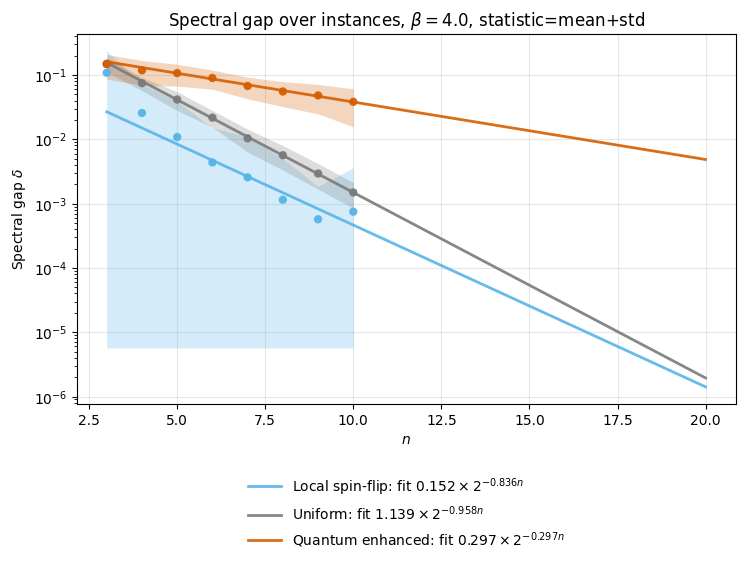

In [13]:
fix, ax = plot_spectral_gap_vs_n(fixed_beta=4.0, n_plot_min=3, n_plot_max=20, statistic="mean+std")

To avoid this issue, we can rely on different statistics, such as `mean+std-tail`, which computes the mean and standard deviation over the central quartiles, or `median+mad`, which computes the median and median absolute deviation. Both statistics measure a different quantity from `mean+std`: they are closer to the behavior of a typical instance rather than the arithmetic average over all instances. However, they are much more robust to outliers and recover the expected behavior.

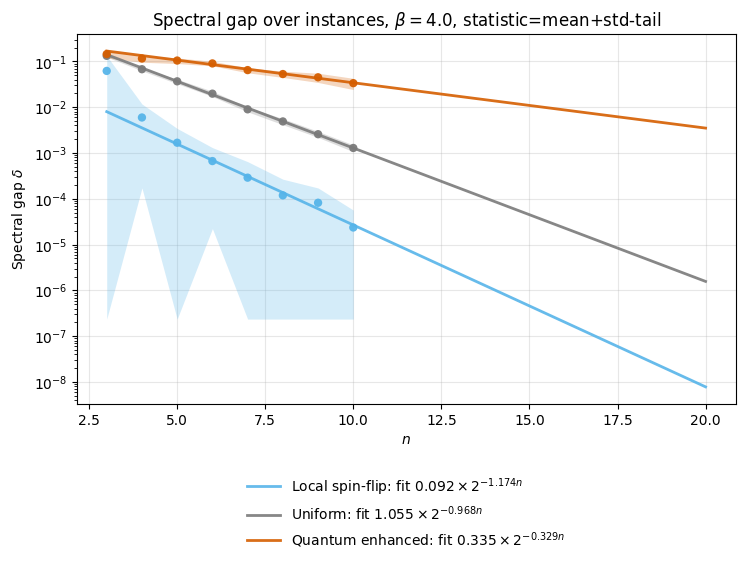

In [14]:
fix, ax = plot_spectral_gap_vs_n(fixed_beta=4.0, n_plot_min=3, n_plot_max=20, statistic="mean+std-tail")

In the paper plots, we report only the best classical and best quantum approaches, and the best classical approach in the low-temperature regime is the uniform move.

## Classical queries calculation

For each transition matrix, we define the number of moves required by classical MCMC (which we refer to as *classical queries*) as the first Markov-chain time at which the distribution obtained from $q_0$ is within total-variation distance $\epsilon$ from the target Gibbs distribution $\pi$. 

For reversible chains, instead of evolving $q_t$ directly, we usually evolve the normalized deviation $g_t=(q_t-\pi)/\sqrt{\pi}$ in the eigenbasis of the symmetric discriminant matrix $X_{xy}=\sqrt{P_{xy}P_{yx}}$. This gives a stable spectral representation of the convergence whenever $\min_x\pi_x$ is above the spectral tolerance $10^{-8}$. When $\min_x\pi_x$ is too small, the normalization by $\sqrt{\pi}$ becomes ill-conditioned, so we compute the convergence by direct evolution of $q_t=P^tq_0$ instead.


The number of classical queries depends primarily on the inverse spectral gap, while the initial distribution contributes through a smaller logarithmic factor. For the comparison later, it is important to simulate a warm-start setting: instead of always starting from the uniform distribution, we also consider an initial Gibbs distribution at a higher temperature, chosen to have a guaranteed Bhattacharyya overlap with the target distribution. This is the setting needed for simulated annealing, where each intermediate distribution should provide a warm start for the next one.

The code below computes the number of classical queries for transition matrices:

* for all system sizes $n=3,\ldots,10$ and all instance indices $\mathrm{idx}=0,\ldots,99$;
* for all inverse temperatures
  $$
  \beta\in\{0.01,0.02,\ldots,0.10,0.20,0.30,\ldots,1.00,2,3,\ldots,10,20,30,\ldots,100\};
  $$
* for all total-variation tolerances $\epsilon\in\{10^{-2},10^{-3},\ldots,10^{-8}\}$;
* for all proposal rules `uniform`, `local1`, `local2`, `local3`, `qemc`, and `layden`;
* for the Metropolis-Hastings acceptance rule, corresponding to the parameter $a=\infty$. Only a subset of the results is currently computed for the Glauber rule ($a=1$), and for the generalized Glauber rule with exponent $10$ ($a=10$);
* for the two initialization modes `uniform` and `bhattacharyya`. In the first case, $q_0$ is the uniform distribution, corresponding to $\beta_0=0$. In the second case, $q_0$ is a Gibbs distribution at an inverse temperature $\beta_0\le \beta$ chosen so that its Bhattacharyya overlap with the target distribution is at least $e^{-1/2}$.

The simulation is run with the following command (**warning! takes time**). 

In [ ]:
# run_experiment_to_generate_classical_queries(n_list=[3, 4, 5])

## Classical queries plots

These plots show how the number of classical queries scales with $n$. Again, we are interested in the low-temperature regime.

Specifically, these plots show the number of classical queries needed to reach the target distribution up to a specified tolerance $\varepsilon$, starting from a distribution with a guaranteed warm start. We can optionally show the inverse spectral gap on the right $y$-axis. We expect the number of classical queries and the inverse spectral gap to scale in a comparable way, up to the contribution of the initial distribution.

We recall that the inverse spectral gap gives a worst-case scaling, which would be achieved only if the initial distribution had full support on the slowest mode of the chain. In practice, the initial distribution is a linear combination of both fast and slow modes. The slow modes require more time to decay, but the projection onto the very slowest mode can sometimes be so small that eliminating it has little practical effect. As a result, the observed query scaling may not be controlled by the inverse spectral gap. Of course, as $\varepsilon\to 0$, even such small contributions become increasingly relevant.

In our plots, the scaling of the inverse spectral gap and of the number of classical queries is comparable. An exception is again the ill-behaved local move, whose deviation is too large to obtain a useful fit (note the large prefactor!). This is not an issue, since the local move is not the best classical approach.


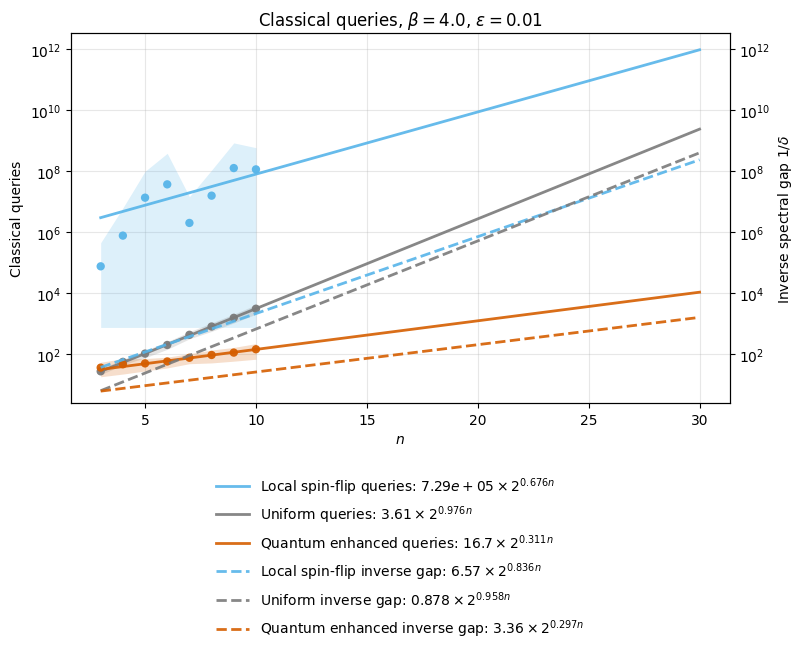

In [26]:
fig, ax, ax_gap = plot_last_step_classical_queries_and_spectral_gap_vs_n(beta=4.0, epsilon=1e-2, show_inverse_gap=True, n_plot_min=3, n_plot_max=30)

Potentially, you can try different statistics, too. 